In [1]:
# Importing libraries to be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore") # Suppress warning messages for cleaner output

In [2]:
df = pd.read_csv("../data/dataset.csv")
df = df.drop(columns=["Unnamed: 0"]) # Remove unnecessary index column created during CSV export
df

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,112.900002,118.800003,107.142998,115.910004,0.000000e+00,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,3.493130,3.692460,3.346060,3.590890,0.000000e+00,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,115.980003,124.663002,106.639999,112.300003,0.000000e+00,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3.594220,3.781020,3.116020,3.371250,0.000000e+00,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,112.250000,113.444000,97.699997,111.500000,0.000000e+00,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07
...,...,...,...,...,...,...,...,...,...
72941,0.022604,0.022988,0.022197,0.022796,4.040134e+07,1.652957e+09,2022-10-23T23:59:59.999Z,VeChain,2022-10-23
72942,1.468244,1.530464,1.435415,1.517878,2.844351e+07,1.572825e+09,2022-10-23T23:59:59.999Z,Flow,2022-10-23
72943,4.950431,5.148565,4.945280,5.117206,1.069497e+08,1.559551e+09,2022-10-23T23:59:59.999Z,Filecoin,2022-10-23
72944,0.000233,0.000243,0.000226,0.000239,2.143268e+08,1.576291e+09,2022-10-23T23:59:59.999Z,Terra Classic,2022-10-23


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         72946 non-null  float64
 1   high         72946 non-null  float64
 2   low          72946 non-null  float64
 3   close        72946 non-null  float64
 4   volume       72946 non-null  float64
 5   marketCap    72946 non-null  float64
 6   timestamp    72946 non-null  str    
 7   crypto_name  72946 non-null  str    
 8   date         72946 non-null  str    
dtypes: float64(6), str(3)
memory usage: 5.0 MB


In [4]:
df.describe()

,open,high,low,close,volume,marketCap
count,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


In [5]:
df["crypto_name"].nunique()

56

In [6]:
df["crypto_name"].unique()

<StringArray>
[              'Bitcoin',              'Litecoin',                   'XRP',
              'Dogecoin',                'Monero',               'Stellar',
                'Tether',              'Ethereum',      'Ethereum Classic',
                 'Maker', 'Basic Attention Token',                   'EOS',
          'Bitcoin Cash',                   'BNB',                  'TRON',
          'Decentraland',             'Chainlink',               'Cardano',
              'Filecoin',         'Theta Network',           'Huobi Token',
             'Ravencoin',                 'Tezos',               'VeChain',
                 'Quant',              'USD Coin',                'Cronos',
       'Wrapped Bitcoin',                'Cosmos',               'Polygon',
                   'OKB',          'UNUS SED LEO',              'Algorand',
                'Chiliz',             'THORChain',         'Terra Classic',
             'FTX Token',                'Hedera',           'Binance USD'

In [7]:
# Object --> Datetime
df['date'] = pd.to_datetime(df['date'])
# Sorting according to date
df = df.sort_values('date')

In [8]:
df.duplicated().sum()

np.int64(0)

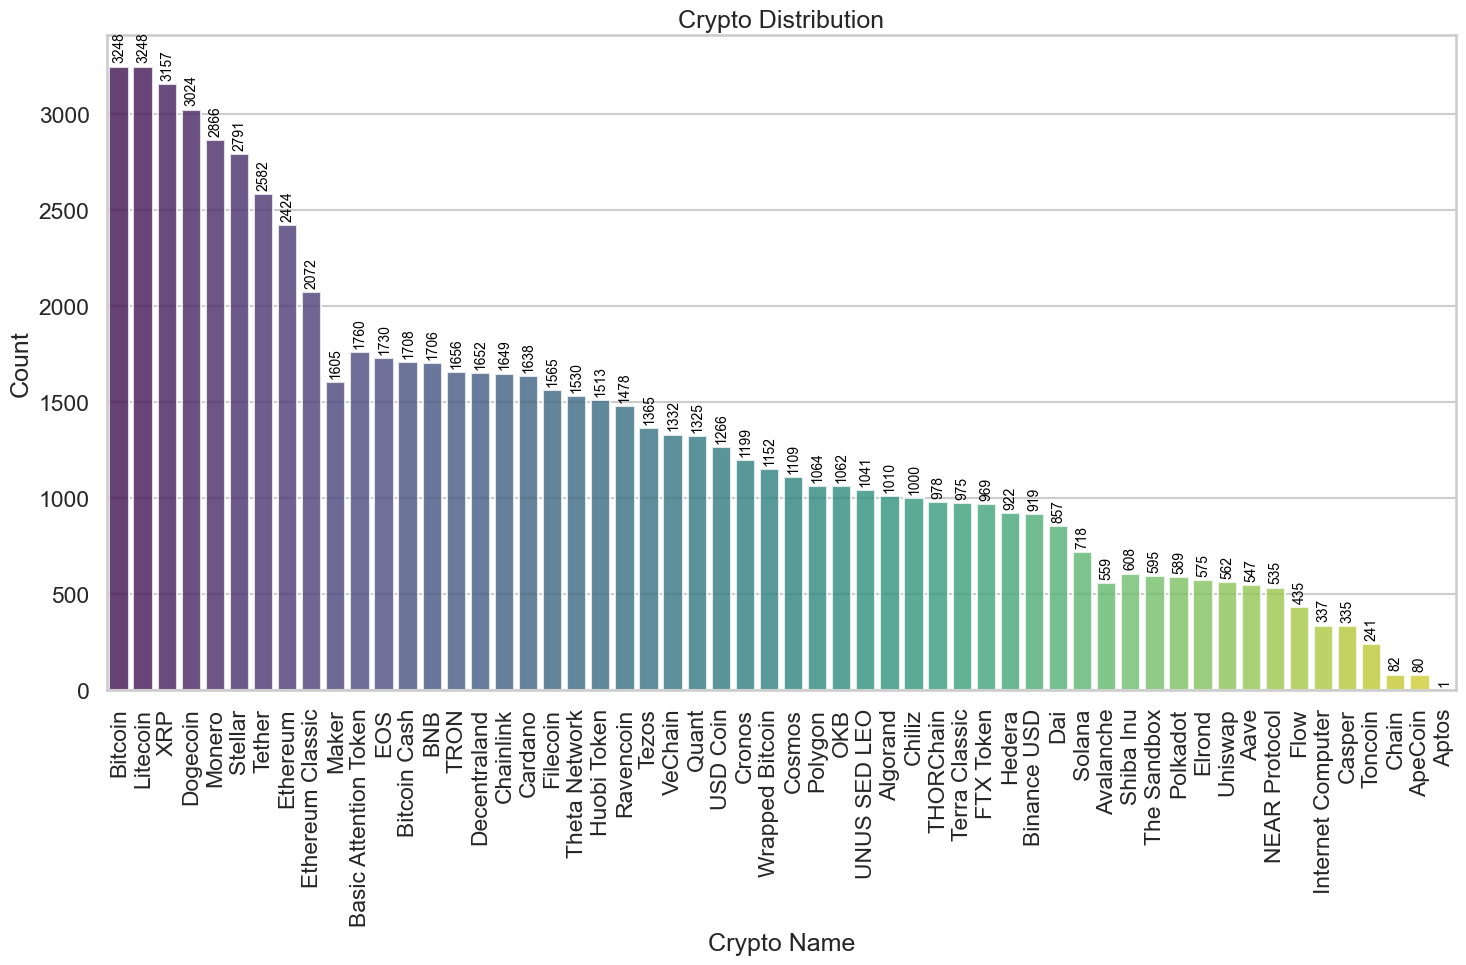

In [9]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(15, 10))
ax = sns.countplot(x='crypto_name', data=df, palette="viridis", alpha=0.8)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.title("Crypto Distribution")
plt.xlabel("Crypto Name")
plt.ylabel("Count")
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='edge', # Place label at the top edge of each bar
        padding=3,
        rotation=90, # Rotate labels vertically to avoid overlap
        fontsize=10,
        color='black'
    )

plt.show()

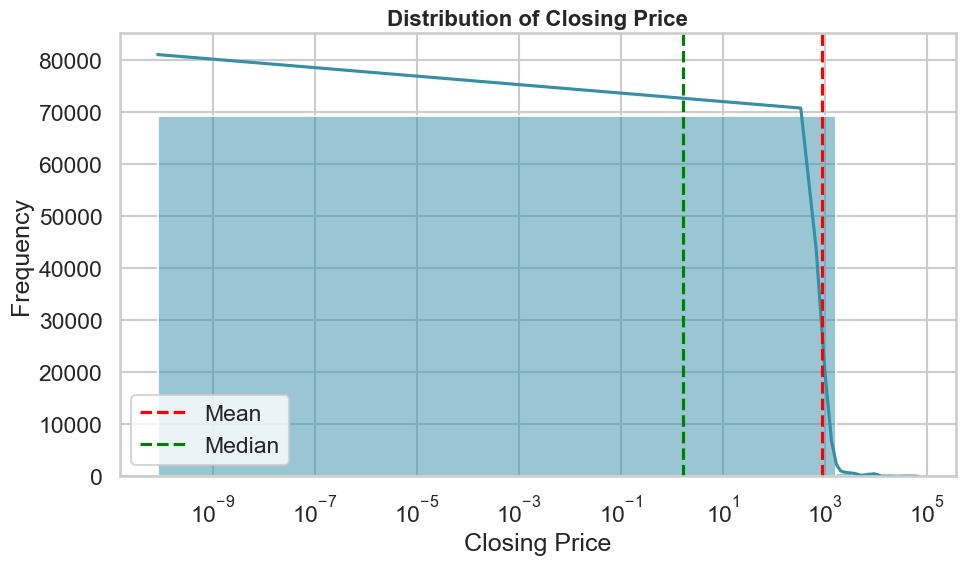

In [10]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(df["close"], bins=40, kde=True, color=sns.color_palette("mako")[3])

plt.axvline(df["close"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["close"].median(), color="green", linestyle="--", label="Median")

plt.title("Distribution of Closing Price", fontsize=16, fontweight="bold")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.legend()

plt.xscale("log") # Use log scale to better visualize skewed crypto price distribution

plt.tight_layout()
plt.show()

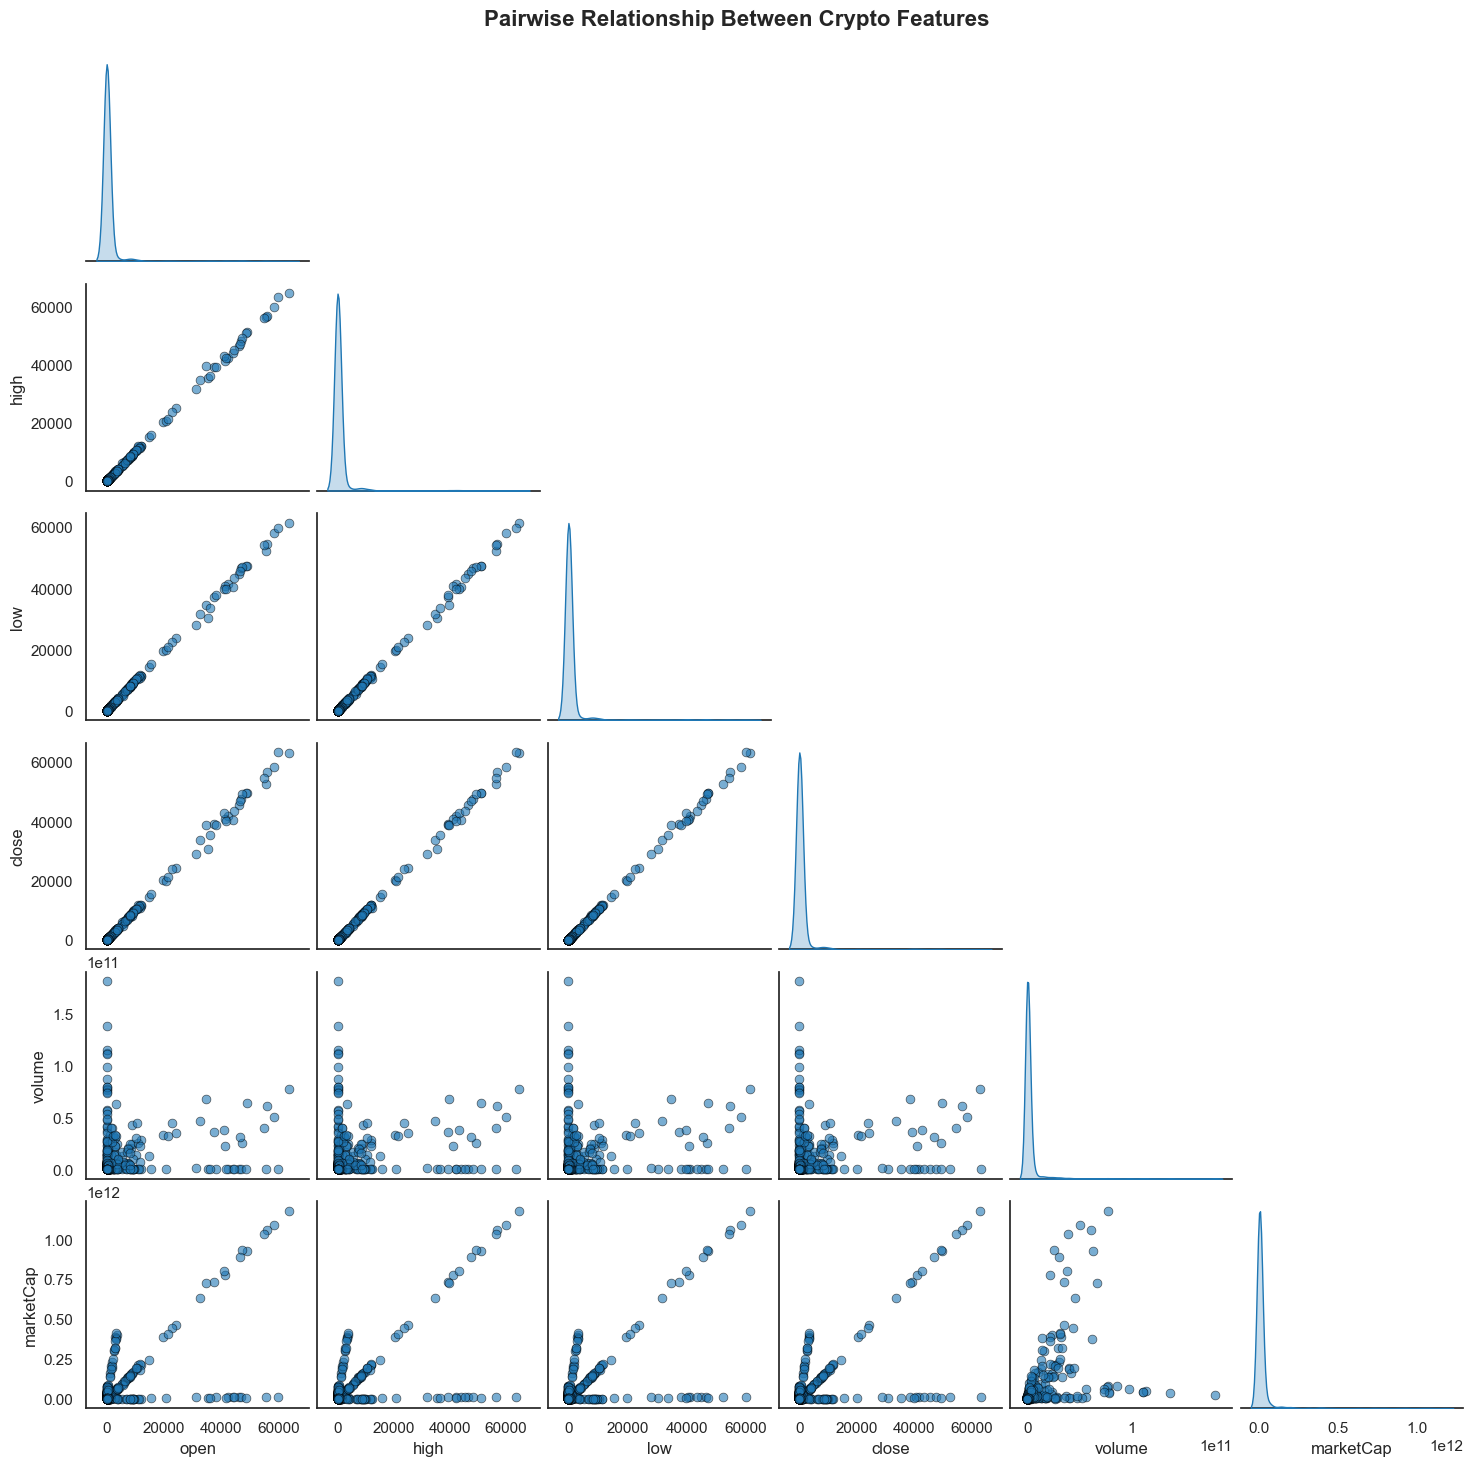

In [11]:
sns.set_style("white")
sns.set_context("notebook")

# Select numerical columns for pairwise relationship analysis
cols = ["open", "high", "low", "close", "volume", "marketCap"]

# Dataset is large, so sample 2000 rows to make pairplot faster and clearer
df_sample = df.sample(2000, random_state=42)

# Pairplot
g = sns.pairplot(
    df_sample[cols],
    diag_kind="kde", # KDE on diagonal for smoother distribution visualization
    corner=True, # Show only lower triangle to remove duplicate plots
    plot_kws={"alpha":0.6, "s":40, "edgecolor":"black"},
    diag_kws={"fill":True},
    palette="viridis"
)

# Title
g.fig.suptitle("Pairwise Relationship Between Crypto Features",
               fontsize=16,
               fontweight="bold")

g.fig.subplots_adjust(top=0.95)

plt.show()

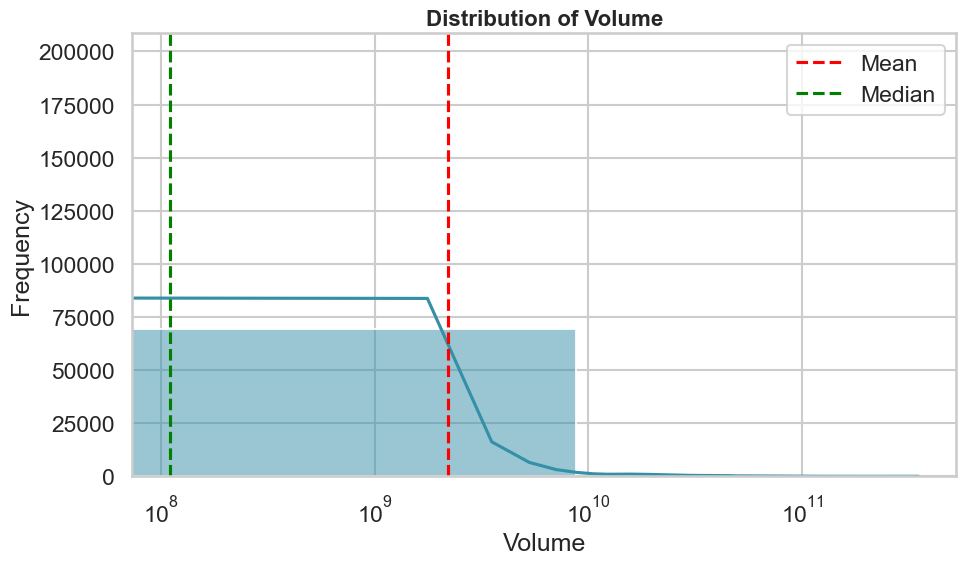

In [12]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(df["volume"], bins=40, kde=True, color=sns.color_palette("mako")[3])

plt.axvline(df["volume"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["volume"].median(), color="green", linestyle="--", label="Median")

plt.title("Distribution of Volume", fontsize=16, fontweight="bold")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.legend()

plt.xscale("log") # Use log scale to better visualize skewed trading volume distribution

plt.tight_layout()
plt.show()

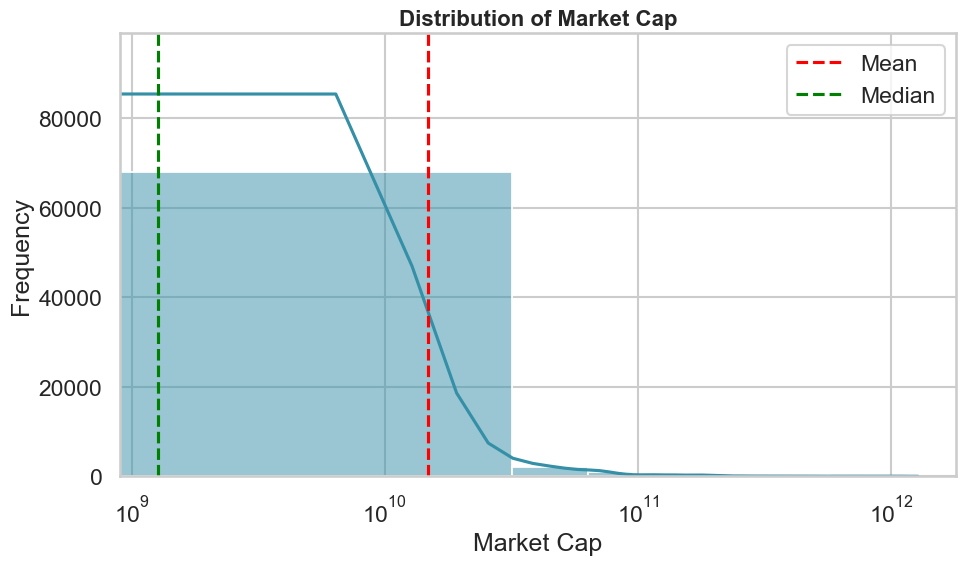

In [13]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(df["marketCap"], bins=40, kde=True, color=sns.color_palette("mako")[3])

plt.axvline(df["marketCap"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["marketCap"].median(), color="green", linestyle="--", label="Median")

plt.title("Distribution of Market Cap", fontsize=16, fontweight="bold")
plt.xlabel("Market Cap")
plt.ylabel("Frequency")
plt.legend()

plt.xscale("log") # Use log scale to better visualize skewed market cap distribution

plt.tight_layout()
plt.show()

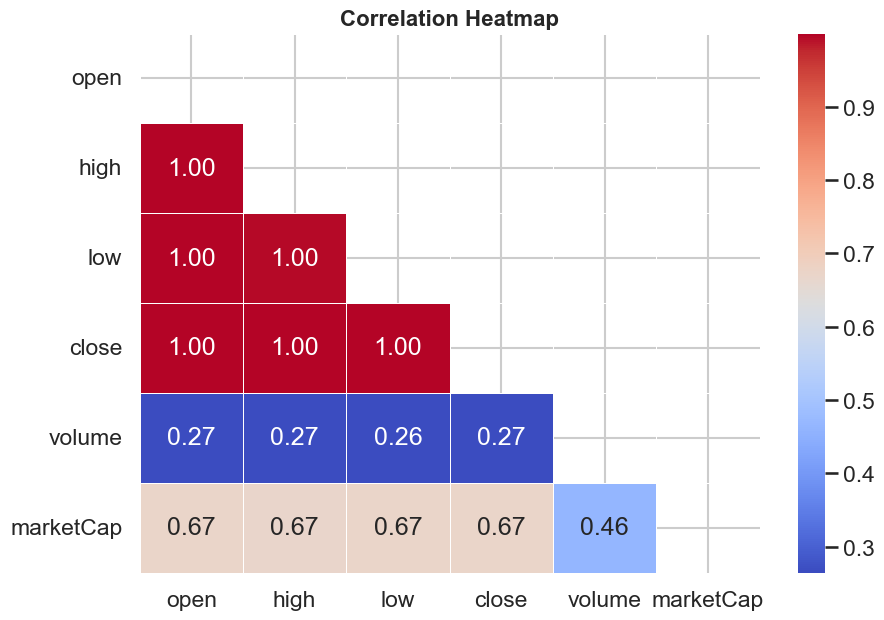

In [14]:
# Select numeric columns for correlation analysis
cols = ["open", "high", "low", "close", "volume", "marketCap"]

corr = df[cols].corr() # Compute correlation matrix between numerical features

mask = np.triu(corr) # Mask upper triangle to avoid duplicate correlations

plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.show()

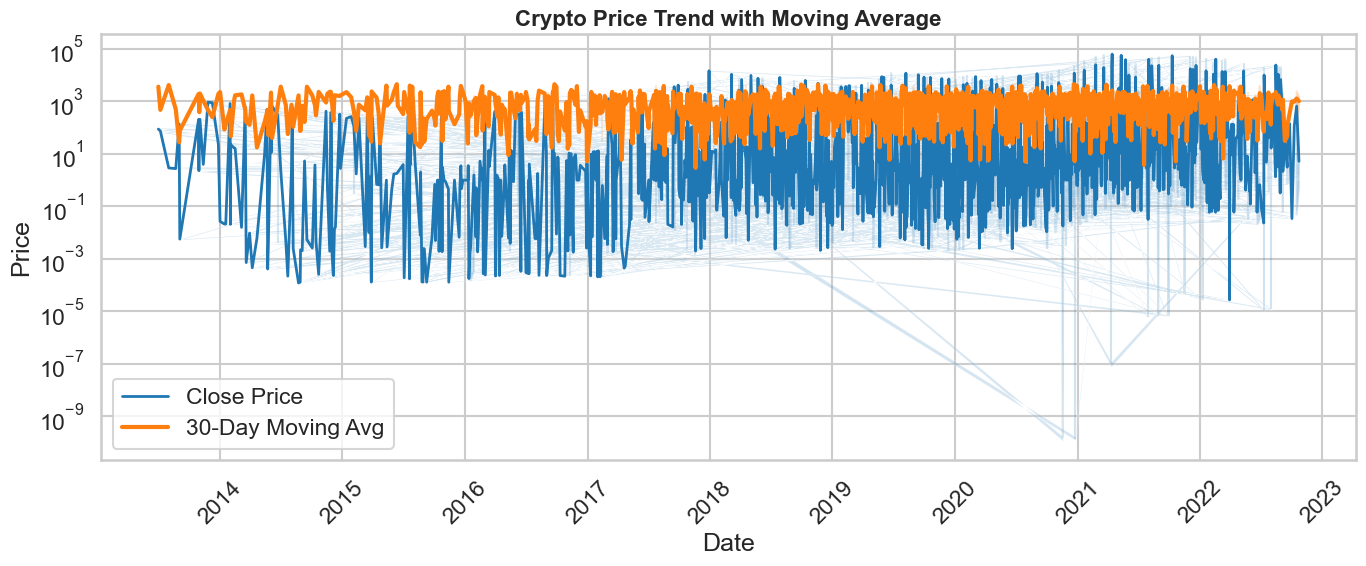

In [15]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")

# Calculate 30-day moving average to smooth short-term price fluctuations
df_sample["MA30"] = df_sample["close"].rolling(30).mean()

plt.figure(figsize=(14,6))

sns.lineplot(data=df_sample, x="date", y="close", label="Close Price", linewidth=2)
sns.lineplot(data=df_sample, x="date", y="MA30", label="30-Day Moving Avg", linewidth=3)

plt.title("Crypto Price Trend with Moving Average", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.yscale("log")  # Use log scale to better visualize large price variations in crypto markets
plt.fill_between(df_sample["date"], df_sample["low"], df_sample["high"], alpha=0.2)

plt.tight_layout()
plt.show()

In [16]:
# Select top 9 most frequent cryptocurrencies for clearer visualization
top_crypto = df_sample["crypto_name"].value_counts().head(9).index
df_plot = df_sample[df_sample["crypto_name"].isin(top_crypto)] # Filter dataset to include only top 9 cryptos

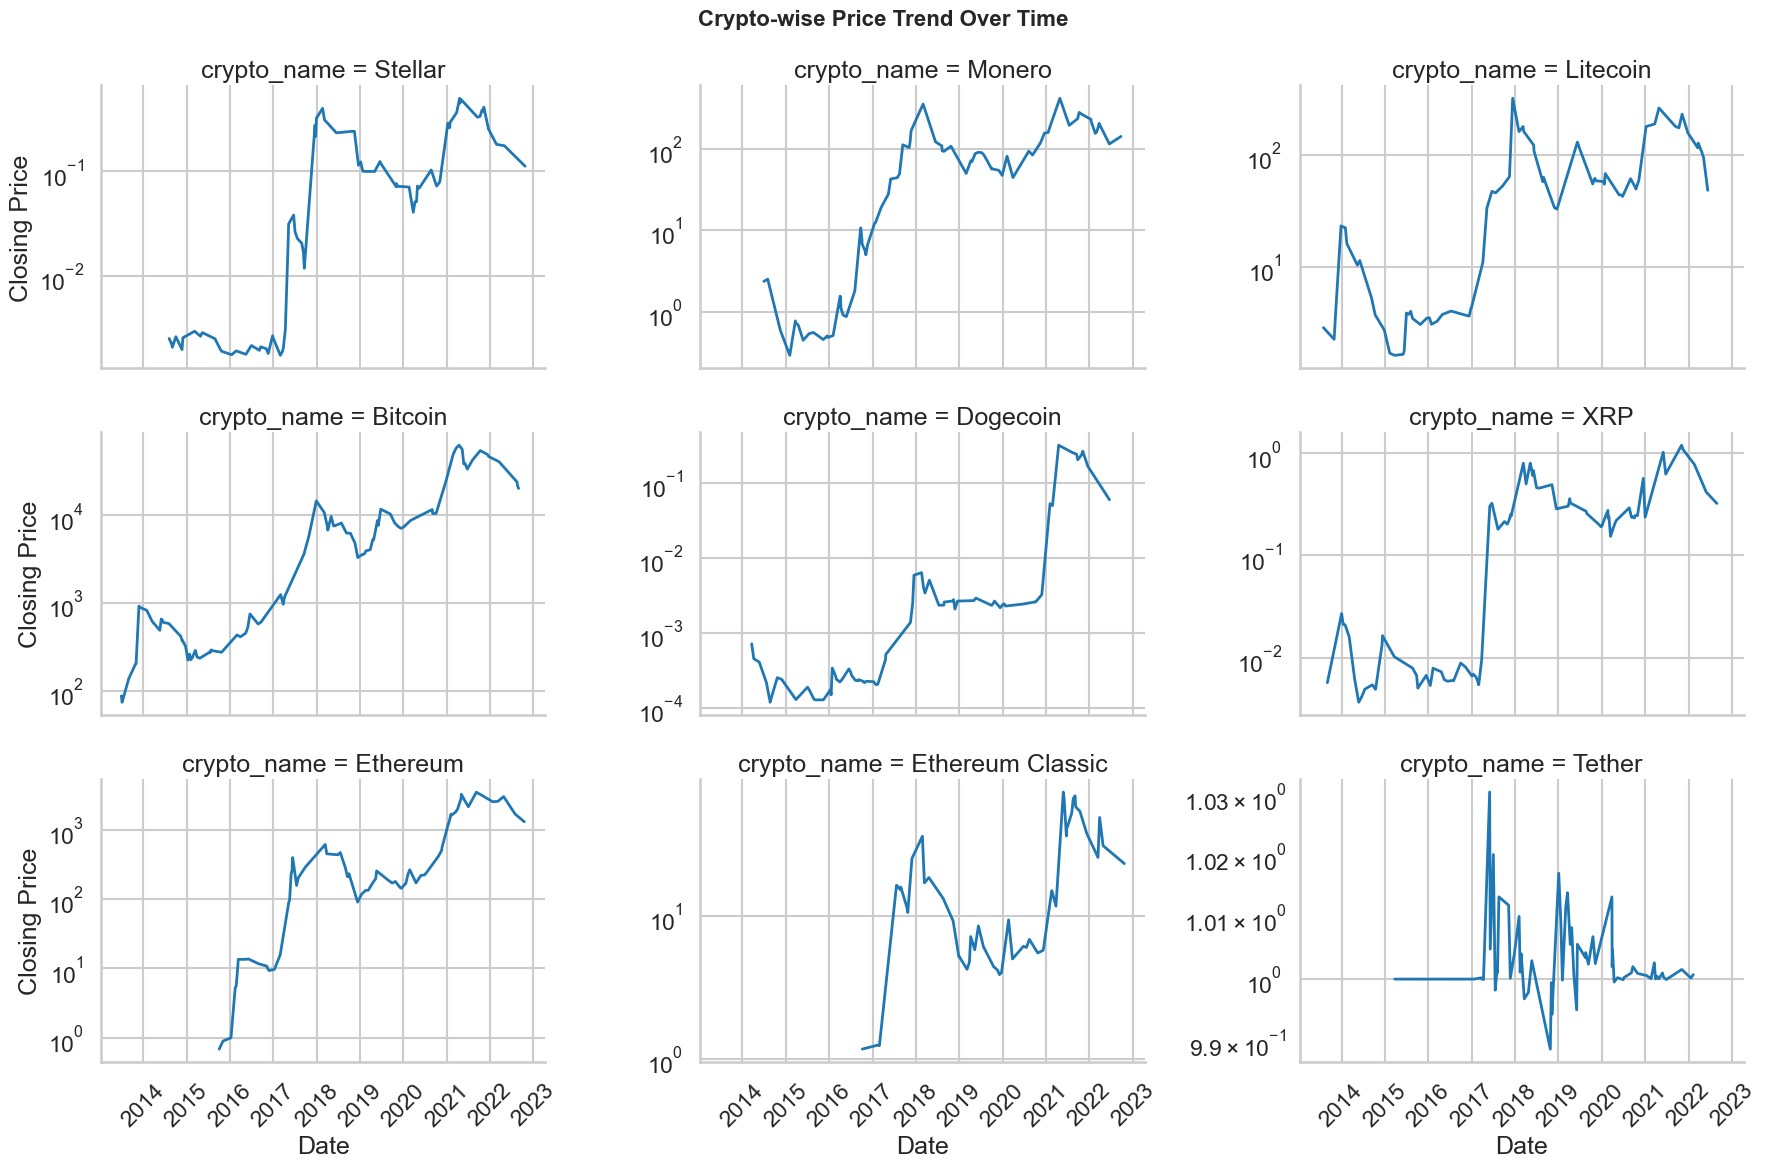

In [17]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")

# Facet plot to show price trend for each cryptocurrency separately
g = sns.relplot(
    data=df_plot,
    x="date",
    y="close",
    col="crypto_name",
    kind="line",
    col_wrap=3, # Arrange plots in a 3-column grid
    height=4,
    aspect=1.5,
    linewidth=2,
    facet_kws={"sharey": False}, # Each crypto gets its own y-scale
)

g.fig.suptitle(
    "Crypto-wise Price Trend Over Time",
    fontsize=16,
    fontweight="bold"
)

g.set_axis_labels("Date", "Closing Price")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45) # Rotate date labels for readability
    ax.set_yscale("log") # Log scale helps visualize large price differences

plt.tight_layout()
plt.show()

In [18]:
# Select bottom 9 least frequent cryptocurrencies
bottom_crypto = df_sample["crypto_name"].value_counts().tail(9).index
df_bottom_plot = df_sample[df_sample["crypto_name"].isin(bottom_crypto)] # Filter dataset to include only these bottom 9 cryptos

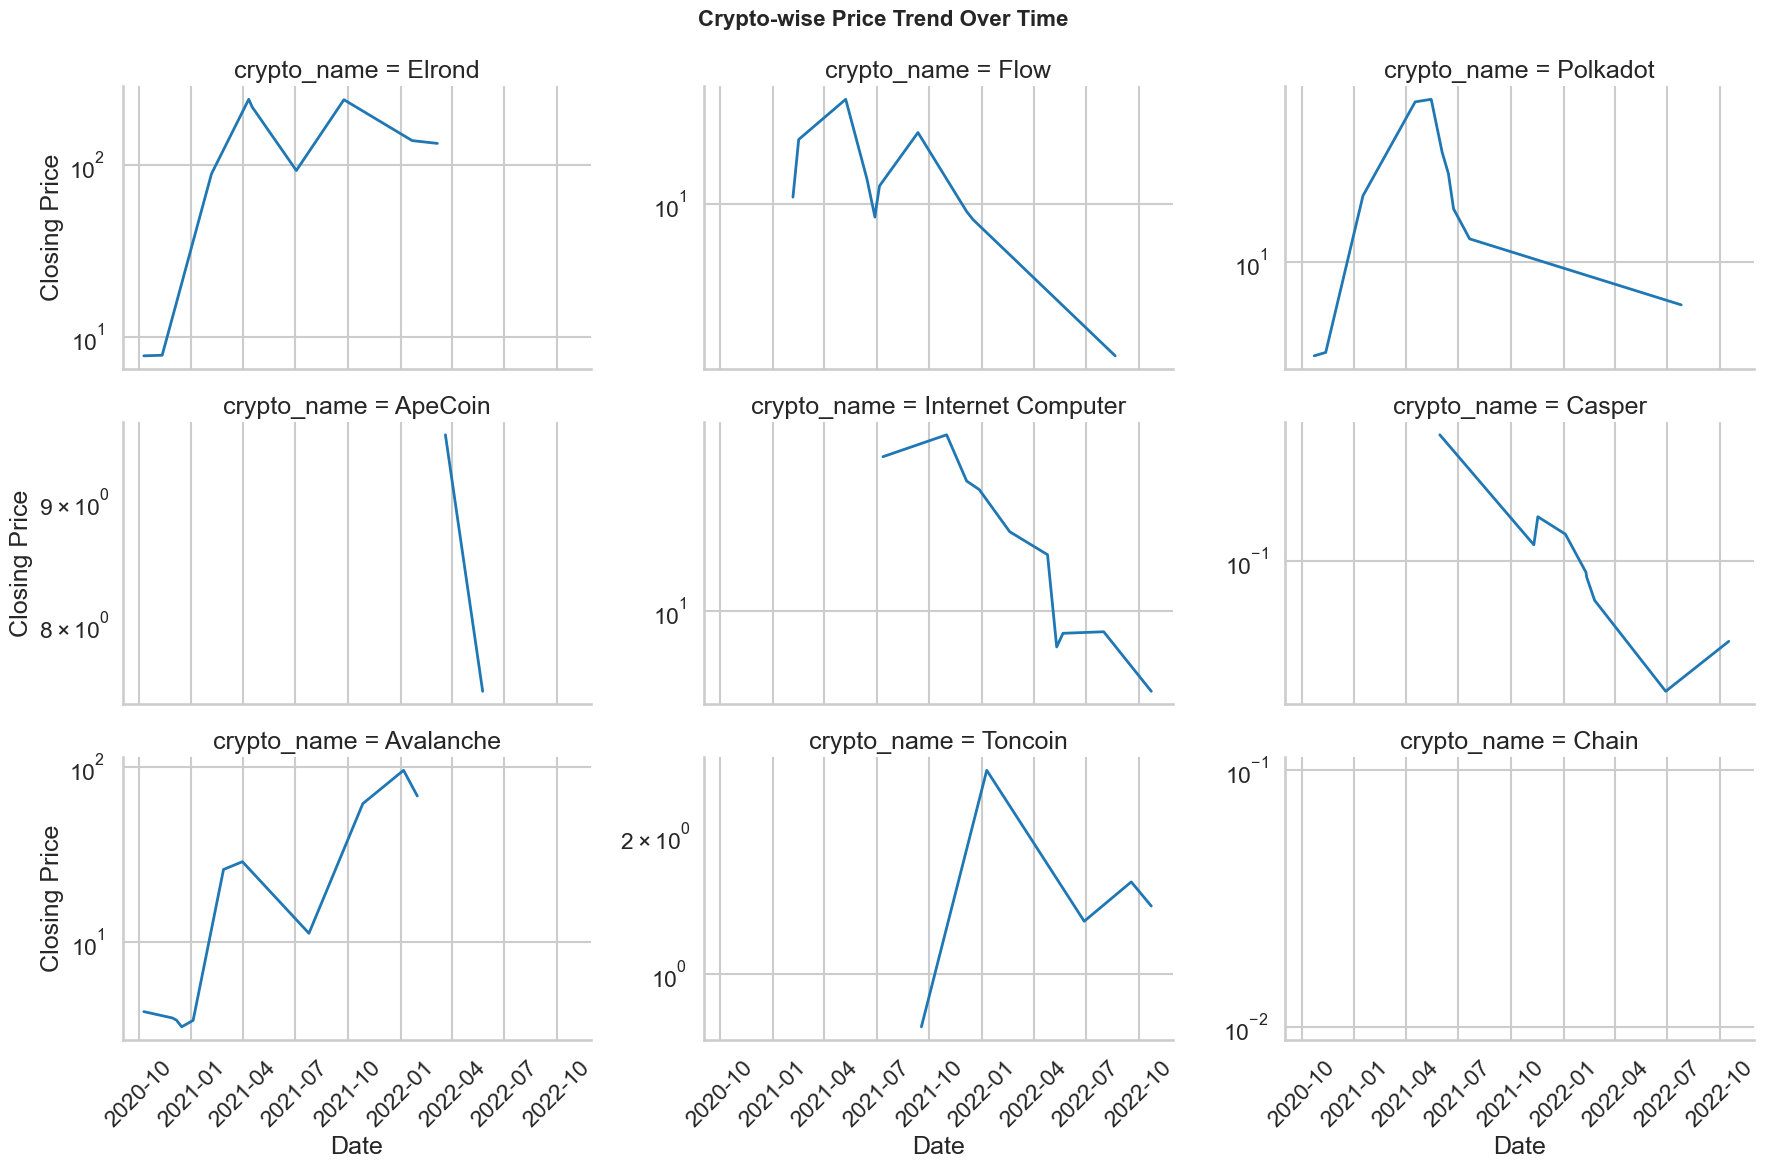

In [19]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")

# Facet plot to show price trend for each cryptocurrency separately
g = sns.relplot(
    data=df_bottom_plot,
    x="date",
    y="close",
    col="crypto_name",
    kind="line",
    col_wrap=3, # Arrange plots in a 3-column grid
    height=4,
    aspect=1.5,
    linewidth=2,
    facet_kws={"sharey": False}, # Each crypto gets its own y-scale
)

g.fig.suptitle(
    "Crypto-wise Price Trend Over Time",
    fontsize=16,
    fontweight="bold"
)

g.set_axis_labels("Date", "Closing Price")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45) # Rotate date labels for readability
    ax.set_yscale("log") # log scale helps visualize large price differences

plt.tight_layout()
plt.show()

In [20]:
# Calculate simple price volatility as percentage price range relative to opening price
df['volatility'] = (df['high'] - df['low']) / df['open']
df_sample['volatility'] = (df_sample['high'] - df_sample['low']) / df_sample['open']

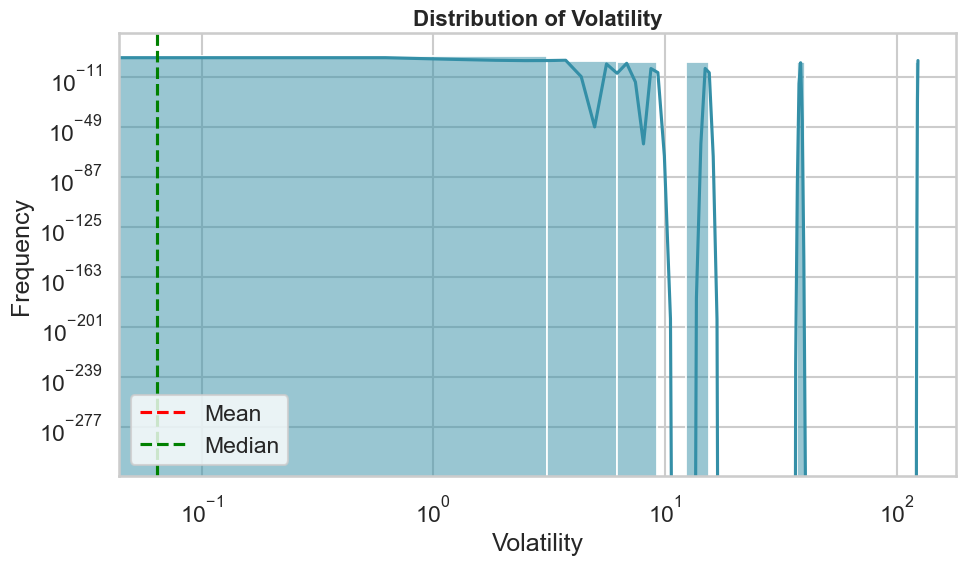

In [21]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(df["volatility"], bins=40, kde=True, color=sns.color_palette("mako")[3])

plt.axvline(df["volatility"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["volatility"].median(), color="green", linestyle="--", label="Median")

plt.title("Distribution of Volatility", fontsize=16, fontweight="bold")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.legend()

plt.xscale("log")  # Log scale helps visualize skewed volatility distribution
plt.yscale("log")  # Log scale improves visibility of frequency differences

plt.tight_layout()
plt.show()

In [22]:
# Calculate percentage returns based on change in closing price
df['returns'] = df['close'].pct_change()
df_sample['returns'] = df_sample['close'].pct_change()

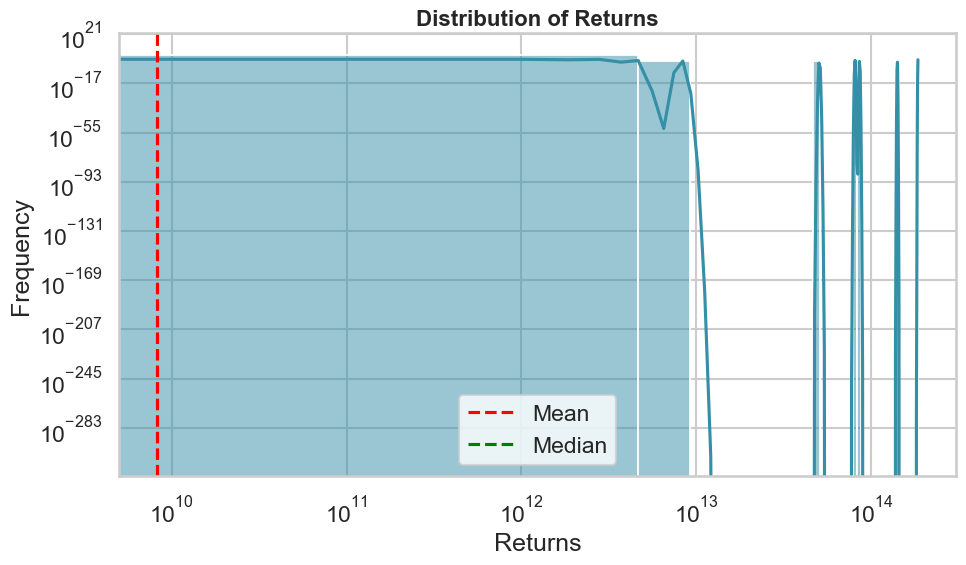

In [23]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(df["returns"], bins=40, kde=True, color=sns.color_palette("mako")[3])

plt.axvline(df["returns"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["returns"].median(), color="green", linestyle="--", label="Median")

plt.title("Distribution of Returns", fontsize=16, fontweight="bold")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.legend()

plt.xscale("log")  # Log scale helps visualize skewed returns distribution
plt.yscale("log")  # Log scale improves visibility of frequency differences

plt.tight_layout()
plt.show()

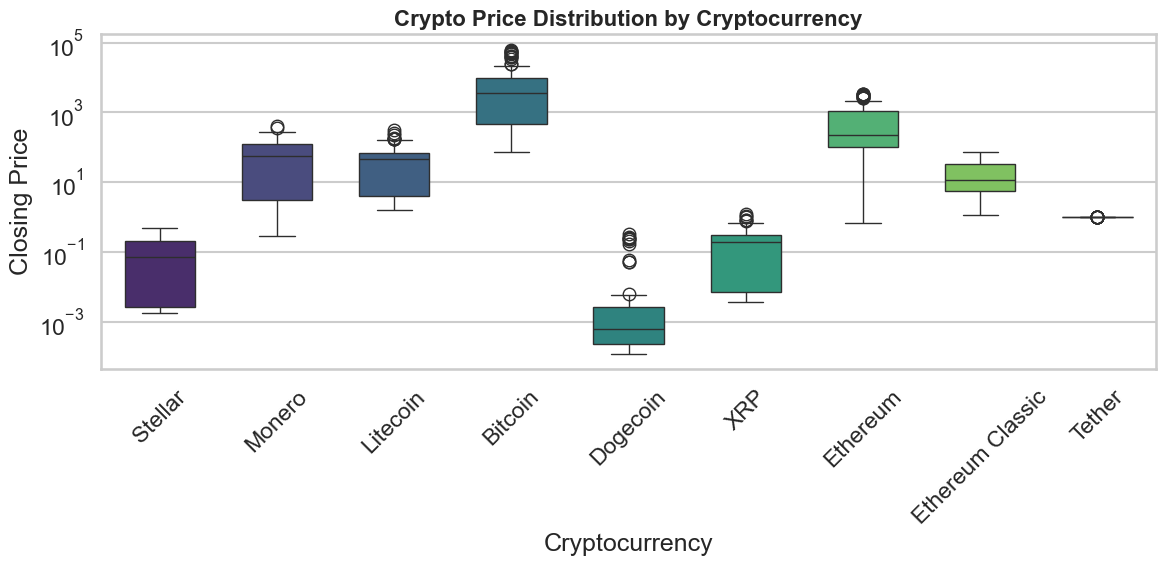

In [24]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(12,6))

# Boxplot to compare price distribution across cryptocurrencies
ax = sns.boxplot(
    data=df_plot,
    x="crypto_name",
    y="close",
    palette="viridis",
    width=0.6
)

# Titles
plt.title("Crypto Price Distribution by Cryptocurrency", fontsize=16, fontweight="bold")
plt.xlabel("Cryptocurrency")
plt.ylabel("Closing Price")

plt.xticks(rotation=45) # Rotate labels for readability
plt.yscale("log") # Log scale helps visualize large price differences between cryptocurrencies

plt.tight_layout()
plt.show()

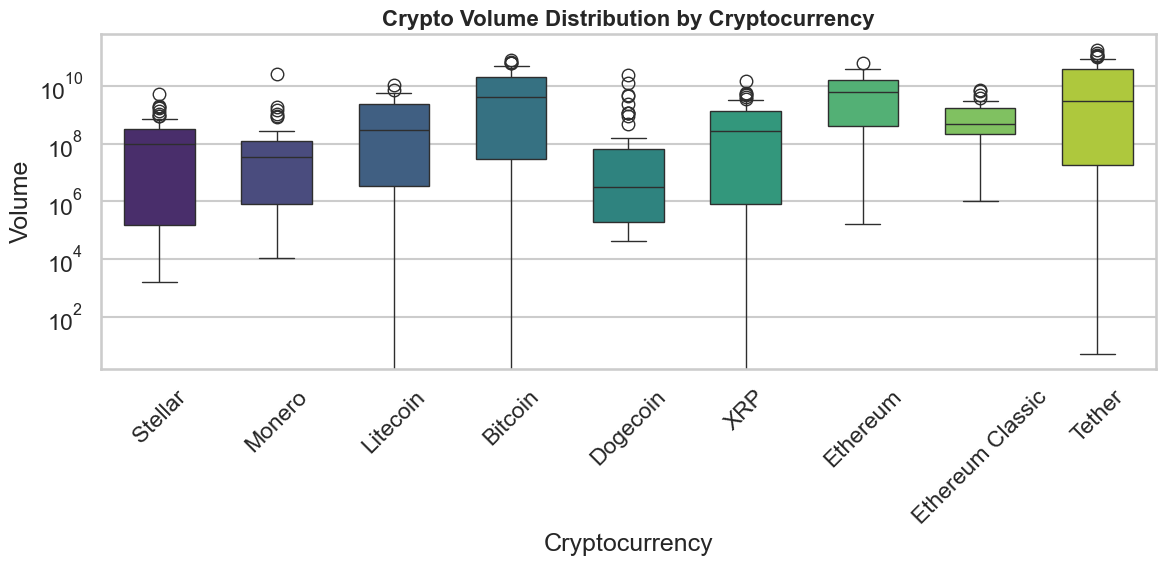

In [25]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(12,6))

# Boxplot to compare price distribution across cryptocurrencies
ax = sns.boxplot(
    data=df_plot,
    x="crypto_name",
    y="volume",
    palette="viridis",
    width=0.6
)

# Titles
plt.title("Crypto Volume Distribution by Cryptocurrency", fontsize=16, fontweight="bold")
plt.xlabel("Cryptocurrency")
plt.ylabel("Volume")

plt.xticks(rotation=45) # Rotate labels for readability
plt.yscale("log")  # Log scale helps visualize large price differences between cryptocurrencies

plt.tight_layout()
plt.show()

In [26]:
# Rolling standard deviation of returns used as a volatility measure
df["volatility_7d"] = df["returns"].rolling(7).std()
df["volatility_30d"] = df["returns"].rolling(30).std()

df_sample["volatility_7d"] = df_sample["returns"].rolling(7).std()
df_sample["volatility_30d"] = df_sample["returns"].rolling(30).std()

# Select top 6 most frequent cryptocurrencies for clearer plotting
top_crypto = df_sample["crypto_name"].value_counts().head(6).index
df_plot = df_sample[df_sample["crypto_name"].isin(top_crypto)]

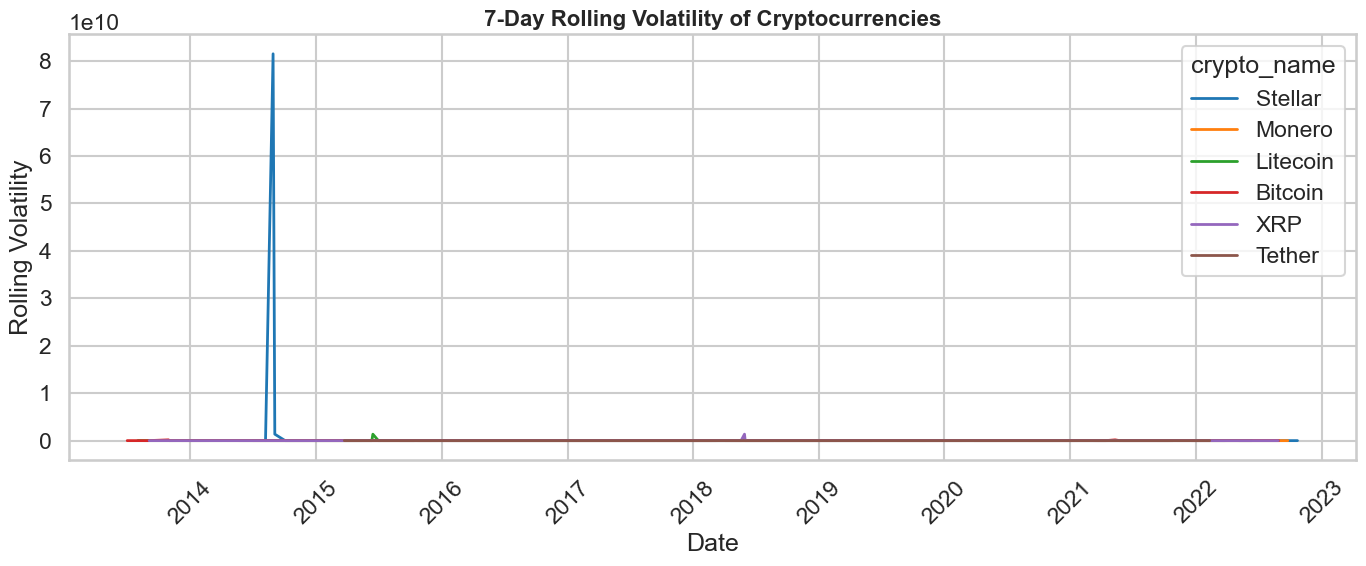

In [27]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14,6))

# Line plot showing short-term (7-day) rolling volatility for selected cryptocurrencies
sns.lineplot(
    data=df_plot,
    x="date",
    y="volatility_7d",
    hue="crypto_name",
    linewidth=2
)

plt.title("7-Day Rolling Volatility of Cryptocurrencies", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.xticks(rotation=45)  # Rotate date labels for better readability

plt.tight_layout()
plt.show()

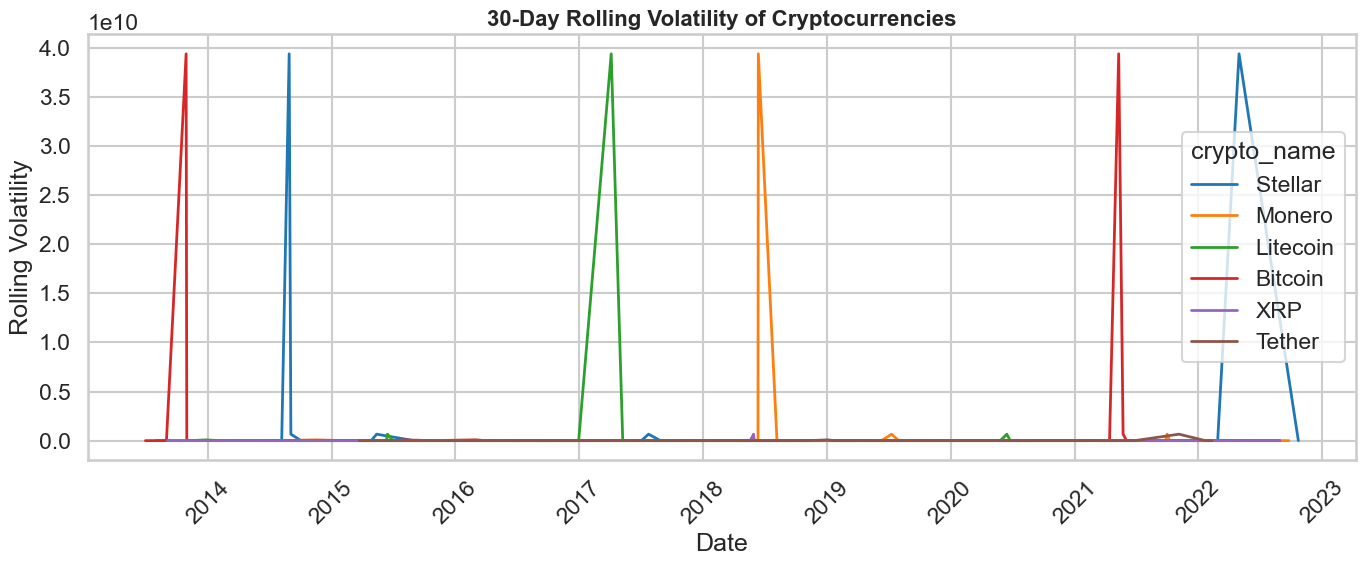

In [28]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14,6))

# Line plot showing longer-term (30-day) rolling volatility for selected cryptocurrencies
sns.lineplot(
    data=df_plot,
    x="date",
    y="volatility_30d",
    hue="crypto_name",
    linewidth=2
)

plt.title("30-Day Rolling Volatility of Cryptocurrencies", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.xticks(rotation=45)  # Rotate date labels for better readability

plt.tight_layout()
plt.show()

In [29]:
# Extract month from date to analyze monthly trends
df_sample["month"] = df_sample["date"].dt.to_period("M")

# Compute monthly average closing price for each cryptocurrency
monthly_trend = df_sample.groupby(["month", "crypto_name"])["close"].mean().reset_index()

# Convert Period type back to timestamp for plotting
monthly_trend["month"] = monthly_trend["month"].dt.to_timestamp()

In [30]:
# Select top 6 most frequent cryptocurrencies for clearer monthly trend visualization
top_crypto = df_sample["crypto_name"].value_counts().head(6).index
monthly_trend = monthly_trend[monthly_trend["crypto_name"].isin(top_crypto)] # Filter monthly trend data to include only these cryptocurrencies

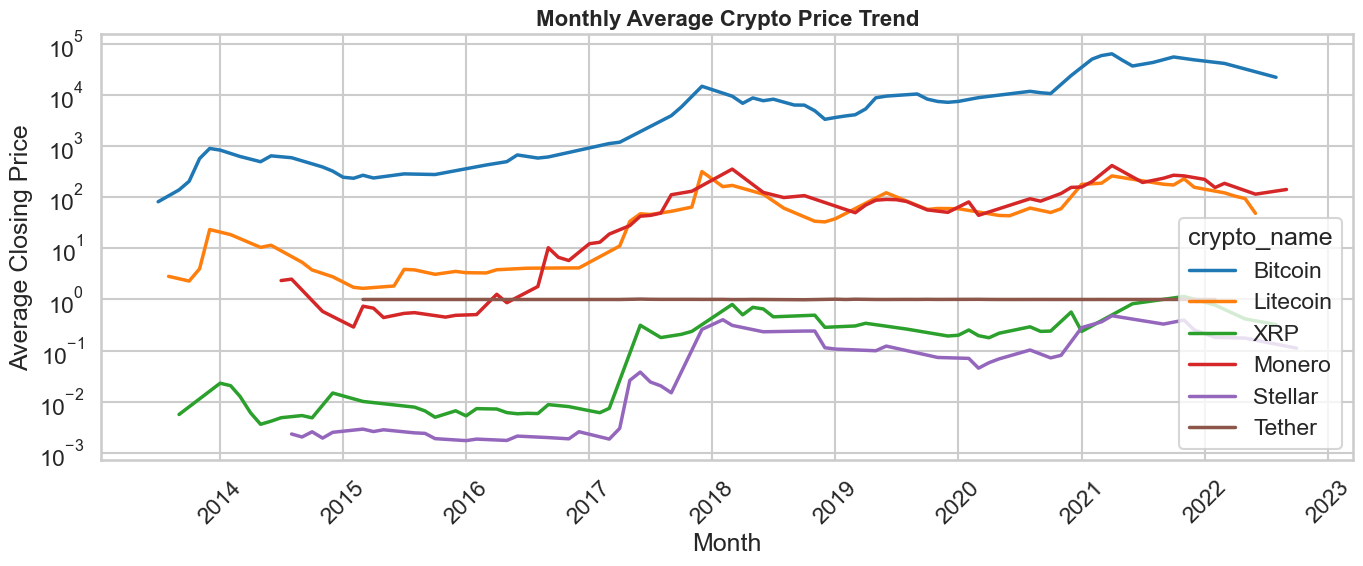

In [31]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14,6))

# Line plot showing monthly average closing price for selected cryptocurrencies
sns.lineplot(
    data=monthly_trend,
    x="month",
    y="close",
    hue="crypto_name",
    linewidth=2.5
)

plt.title("Monthly Average Crypto Price Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")

plt.xticks(rotation=45)  # Rotate month labels for better readability
plt.yscale("log")  # Log scale helps visualize large price differences across cryptocurrencies

plt.tight_layout()
plt.show()

In [32]:
# Calculate average market capitalization for each cryptocurrency and sort in descending order
top = df.groupby('crypto_name')['marketCap'].mean().sort_values(ascending=False)
top.head(10)  # Display top 10 cryptocurrencies by average market capitalization

crypto_name
Bitcoin         1.777921e+11
Ethereum        7.763656e+10
Polkadot        1.971862e+10
BNB             1.774417e+10
Solana          1.521559e+10
Cardano         1.407725e+10
Tether          1.318953e+10
XRP             1.214154e+10
USD Coin        1.146844e+10
Bitcoin Cash    9.151862e+09
Name: marketCap, dtype: float64

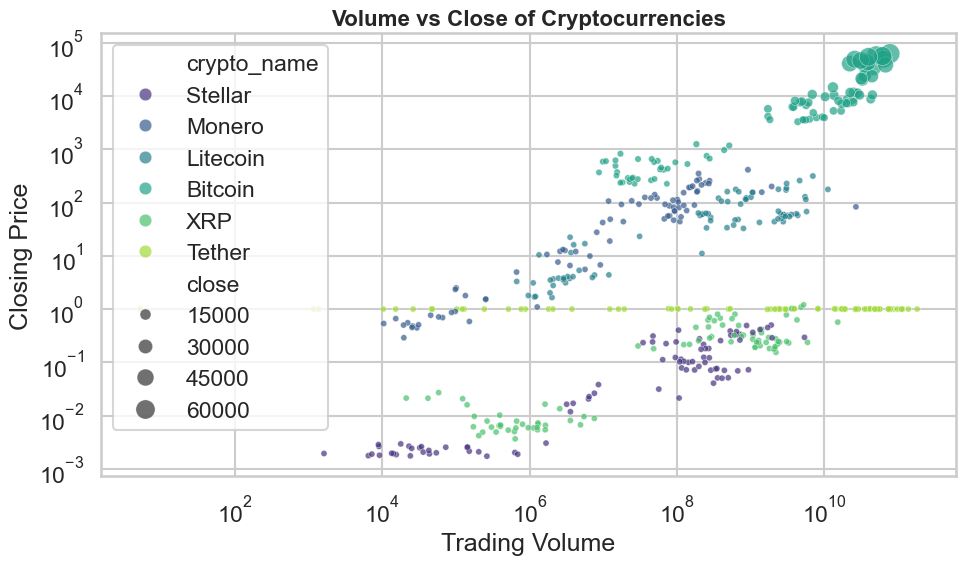

In [33]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

# Scatterplot to visualize relationship between trading volume and closing price
sns.scatterplot(
    data=df_plot,
    x="volume",
    y="close",
    hue="crypto_name",
    size="close",
    sizes=(20,200),
    alpha=0.7,
    palette="viridis"
)

plt.title("Volume vs Close of Cryptocurrencies", fontsize=16, fontweight="bold")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

plt.xscale("log")  # Log scale helps handle very large differences in trading volume
plt.yscale("log")  # Log scale helps visualize large price differences across cryptocurrencies

plt.tight_layout()
plt.show()

In [34]:
# Filter dataset to include only Bitcoin data
btc = df[df["crypto_name"] == "Bitcoin"]

In [35]:
# Create interactive candlestick chart for Bitcoin price movement
fig = go.Figure(data=[go.Candlestick(
    x=btc["date"],
    open=btc["open"],
    high=btc["high"],
    low=btc["low"],
    close=btc["close"],
    increasing_line_color="green",   # Green candles indicate price increase
    decreasing_line_color="red"      # Red candles indicate price decrease
)])

# Customize chart layout
fig.update_layout(
    title="Bitcoin Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_dark",
    height=600
)

fig.show()

In [36]:
df.sort_values('volatility', ascending=False).head(10)

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,volatility,returns,volatility_7d,volatility_30d
55026,0.000000e+00,7.507305e+02,0.000000e+00,4.283623e+02,2.908341e+08,5.300858e+10,2021-05-10T23:59:59.999Z,Internet Computer,2021-05-10,inf,3.078660,1076.748588,180838.116319
44644,0.000000e+00,5.165715e-01,0.000000e+00,5.165715e-01,0.000000e+00,0.000000e+00,2020-10-02T23:59:59.999Z,Aave,2020-10-02,inf,-0.889264,257.571675,486.345661
44709,5.238363e-01,6.530594e+01,5.238014e-01,5.315149e+01,0.000000e+00,0.000000e+00,2020-10-03T23:59:59.999Z,Aave,2020-10-03,123.668655,24.122462,112.630298,44927.280446
68553,1.000397e+00,3.939886e+01,1.000394e+00,8.518083e+00,2.365743e+09,2.363768e+09,2022-03-17T23:59:59.999Z,ApeCoin,2022-03-17,38.383238,-0.901990,535.120598,26371.112017
1584,2.356070e+00,3.778090e+01,1.987200e+00,2.005120e+00,2.346470e+05,5.144309e+06,2014-08-04T23:59:59.999Z,Monero,2014-08-04,15.192120,404.242572,14014.951775,509310.289291
10860,1.815220e-03,1.767100e-02,1.371420e-03,1.831120e-03,5.453470e+04,0.000000e+00,2017-09-16T23:59:59.999Z,TRON,2017-09-16,8.979397,0.016803,109388.292872,674440.554354
50295,1.000000e-08,8.000000e-08,1.000000e-08,3.000000e-08,2.392174e+07,0.000000e+00,2021-01-31T23:59:59.999Z,Shiba Inu,2021-01-31,7.000000,-1.000000,529.055317,1008.145058
10897,3.272870e-03,2.323780e-02,1.745520e-03,2.291310e-03,1.584160e+05,0.000000e+00,2017-09-19T23:59:59.999Z,TRON,2017-09-19,6.566799,-0.999996,406.715233,92852.980253
54931,2.800000e-06,1.897000e-05,2.800000e-06,1.578000e-05,6.118034e+09,6.228541e+09,2021-05-08T23:59:59.999Z,Shiba Inu,2021-05-08,5.775000,-1.000000,862.070091,10806.643163
18456,8.044580e-01,3.982950e+00,8.018290e-01,9.844480e-01,5.009860e+05,0.000000e+00,2018-09-17T23:59:59.999Z,Quant,2018-09-17,3.954366,14.086840,23052.264114,12121.123618


# Exploratory Data Analysis (EDA) Report – Crypto Volatility Dataset
### **1. Price Trend Over Time**
  - Several cryptocurrencies show a consistent increase in price over time, indicating long-term growth.
  - Some cryptocurrencies experienced price decline during certain periods.
  - Few cryptocurrencies showed high price fluctuations in the middle years followed by stabilization in later periods.

### **2. Correlation Analysis**
  - Open, High, Low, and Close prices exhibit very strong positive correlation, which is expected as they represent daily price movements.
  - Market capitalization has a strong positive correlation with closing price.
  - Trading volume shows moderate correlation with market capitalization.
  - Trading volume has relatively low correlation with closing price, indicating price movement is not always directly driven by trading volume.

### **3. Volatility Distribution**
  - Short-term volatility (7-day window) is generally lower compared to long-term volatility (30-day window).
  - Some cryptocurrencies exhibit stable short-term price movements but larger fluctuations over longer periods.

### **4. Volume Impact on Price**
  - In several cases, higher trading volume is associated with increases in cryptocurrency price, suggesting strong market participation during price movements.

### **5. Highest Market Capitalization Cryptocurrency**
  - Bitcoin consistently holds the highest market capitalization among the cryptocurrencies in the dataset.

### **6. Periods of High Volatility**
  - The period 2020 to 2022 experienced the highest levels of volatility, likely due to major market events and increased crypto adoption.

### **Key Features Created**
  - Daily Returns
  - Volatility (High - Low) / Open
  - Rolling Volatility (7-day / 30-day)